# Last.fm bench

Compare embedding recommendations against Last.fm results.

In [1]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

## Data Prep

In [8]:
DATA_DIR = Path("../datasets")
BENCH_PATH = DATA_DIR / "lastfm_recommendations_all_top_listener.csv"
RECS_PATH = DATA_DIR / "recommendations_album_level_avg_embeddings.parquet"
CATALOG_PATH = DATA_DIR / "albums.csv"

# Number of top recommendations to keep for each query album
TOP_N = 4

In [9]:
def keep_top_n(df, top_n=TOP_N):
    """Keep ranks 1..top_n and drop query albums with fewer than top_n recs."""
    df = df[df["rank"] <= top_n].copy()
    keys = ["query_artist", "query_album"]
    n_queries_before = df.groupby(keys, observed=True).ngroups
    n_recs = df.groupby(keys, observed=True)["rank"].transform("count")
    df = df[n_recs >= top_n].reset_index(drop=True)
    n_queries_after = df.groupby(keys, observed=True).ngroups
    print(f"Kept {n_queries_after:,} / {n_queries_before:,} query albums with >={top_n} recs")
    return df


def _norm_str(s) -> str:
    """Same normalization as ingestion/albums.ipynb (quotes, accents, whitespace)."""
    s = str(s).strip().lower()
    for ch in ("\u2019", "\u2018", "\u201b", "\u2032", "`", "\u00b4"):
        s = s.replace(ch, "'")
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return re.sub(r"\s+", " ", s)


def _norm(s: pd.Series) -> pd.Series:
    return s.fillna("").map(_norm_str)


def rec_key(df):
    """Normalized artist::album key for recommended albums."""
    return _norm(df["rec_artist"]) + "::" + _norm(df["rec_album"])

In [10]:
# Load the album catalog from the CSV file containing metadata for all albums reviewed in the dataset
catalog = pd.read_csv(CATALOG_PATH)
catalog["key"] = _norm(catalog["artist"]) + "::" + _norm(catalog["album"])
catalog_reviews = catalog.set_index("key")["review_count"]
catalog_ids = catalog.set_index("key")["album_id"]
print(f"Catalog: {len(catalog):,} albums")

Catalog: 30,516 albums


### Recommendations

Load and sanitize recommendations from our recommender.


In [11]:
recs = pd.read_parquet(RECS_PATH)
recs = recs.drop(columns=["rec_length_flag"])

recs_1 = keep_top_n(recs, 1)
recs_n = keep_top_n(recs)

Kept 44,716 / 44,716 query albums with >=1 recs
Kept 44,716 / 44,716 query albums with >=4 recs


### Last.fm Bench

Load and sanitize recommendations from Last.fm benchmark recommender.

In [12]:
df = pd.read_csv(BENCH_PATH)
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["rank"] = pd.to_numeric(df["rank"], errors="coerce")

# keep successful recommendations only
df = df[df["status"] == "ok"].reset_index(drop=True)

n_albums = df["album_id"].nunique()
print(f"File: {BENCH_PATH.name}")
print(f"Strategy: {df['strategy'].iloc[0]}  |  Albums: {n_albums:,}  |  Rec rows: {len(df):,}")
df.head(5)

File: lastfm_recommendations_all_top_listener.csv
Strategy: top_listener  |  Albums: 1,702  |  Rec rows: 7,024


,album_id,artist,album,review_count,strategy,status,error,seed_track,seed_listeners,rec_artist,rec_album,score,rank,rec_listeners
0,10960,Indigo Girls,Poseidon and the Bitter Bug,1,top_listener,ok,NaN,Sugar Tongue,10042.0,Bruce Cockburn,Guitar Gods Vol. 3 (Live),0.317808,1.0,8.0
1,10960,Indigo Girls,Poseidon and the Bitter Bug,1,top_listener,ok,NaN,Sugar Tongue,10042.0,Cowboy Junkies,200 More Miles,0.238679,2.0,2696.0
2,10960,Indigo Girls,Poseidon and the Bitter Bug,1,top_listener,ok,NaN,Sugar Tongue,10042.0,Tracy Chapman,Live & Alive,0.216455,3.0,275.0
3,10811,Ida,Lovers Prayers,1,top_listener,ok,NaN,Lovers Prayers,16583.0,The Secret Stars,The Secret Stars,1.000000,1.0,2380.0
4,10811,Ida,Lovers Prayers,1,top_listener,ok,NaN,Lovers Prayers,16583.0,The American Analog Set,Know by Heart,0.993583,2.0,292488.0


In [13]:
baseline = df.rename(columns={
    "artist": "query_artist",
    "album":  "query_album",
}).reindex(columns=[
    "album_id", "query_artist", "query_album", "rec_artist", "rec_album",
    "score", "rank", "seed_listeners", "rec_listeners",
]).copy()


baseline_n = keep_top_n(baseline)
baseline_1 = keep_top_n(baseline, 1)

Kept 1,338 / 1,702 query albums with >=4 recs
Kept 1,702 / 1,702 query albums with >=1 recs


In [14]:
baseline_n.head(6)

,album_id,query_artist,query_album,rec_artist,rec_album,score,rank,seed_listeners,rec_listeners
0,10811,Ida,Lovers Prayers,The Secret Stars,The Secret Stars,1.000000,1.0,16583.0,2380.0
1,10811,Ida,Lovers Prayers,The American Analog Set,Know by Heart,0.993583,2.0,16583.0,292488.0
2,10811,Ida,Lovers Prayers,Cat Power,You Are Free,0.799562,3.0,16583.0,591532.0
3,10811,Ida,Lovers Prayers,Someone Still Loves You Boris Yeltsin,Broom,0.790617,4.0,16583.0,337203.0
4,5817,David Axelrod,David Axelrod,Marc Copland,Time Within Time,1.000000,1.0,7165.0,147.0
5,5817,David Axelrod,David Axelrod,DJ Okawari,Kaleidoscope,0.999960,2.0,7165.0,47065.0


In [15]:
baseline_1.head(6)

,album_id,query_artist,query_album,rec_artist,rec_album,score,rank,seed_listeners,rec_listeners
0,10960,Indigo Girls,Poseidon and the Bitter Bug,Bruce Cockburn,Guitar Gods Vol. 3 (Live),0.317808,1.0,10042.0,8.0
1,10811,Ida,Lovers Prayers,The Secret Stars,The Secret Stars,1.000000,1.0,16583.0,2380.0
2,5817,David Axelrod,David Axelrod,Marc Copland,Time Within Time,1.000000,1.0,7165.0,147.0
3,1682,Augie March,Strange Bird,Paul Kelly,Paul Kelly's Greatest Hits: Songs From The Sou...,0.826532,1.0,23212.0,31522.0
4,30023,Xiu Xiu,Plays the Music of Twin Peaks,Swans,Soundtracks for the Blind,0.103711,1.0,112067.0,226461.0
5,14217,Lil Durk,300 Days 300 Nights,Only The Family,Rememberance (feat. Lil Durk),0.581710,1.0,33155.0,92.0


### Match to baseline queries

Keep only embedding recs whose query album appears in the Last.fm baseline (normalized artist::album match).

In [29]:
baseline_query_keys = set(
    _norm(baseline["query_artist"]) + "::" + _norm(baseline["query_album"])
)

def filter_to_baseline(df):
    in_baseline = (
        _norm(df["query_artist"]) + "::" + _norm(df["query_album"])
    ).isin(baseline_query_keys)
    out = df.loc[in_baseline].reset_index(drop=True)
    n_queries = out.groupby(["query_artist", "query_album"], observed=True).ngroups
    print(f"{len(out):,} rows, {n_queries:,} queries")
    return out

print("Embedding recs (matched to baseline):")
recs_1 = filter_to_baseline(recs_1)
recs_n = filter_to_baseline(recs_n)

Embedding recs (matched to baseline):
1,710 rows, 1,710 queries
6,840 rows, 1,710 queries


# Comparisons

Each recommender has two views: `*_1` (rank-1 only — top-pick metrics) and `*_n` (full top-N lists — list-level metrics). Embedding recs are restricted to query albums present in the Last.fm baseline.


## Repeated Albums

How concentrated are rank-1 recommendations? Few unique albums with many repeats means the recommender funnels different queries to the same hubs.

In [30]:
def repeated_albums(df, label, rec_col="rec_album"):
    counts = df[rec_col].str.strip().str.lower().value_counts()
    n_total = len(df)
    n_unique = counts.size
    n_repeated = (counts > 1).sum()
    print(f"[{label}]")
    print(f"  Total:    {n_total:,}")
    print(f"  Unique:   {n_unique:,}  ({n_unique / n_total:.1%})")
    print(f"  Repeated: {n_repeated:,}  ({n_repeated / n_unique:.1%} of unique)")
    print()


repeated_albums(recs_1, "embedding recs")
repeated_albums(baseline_1, "last.fm baseline")

[embedding recs]
  Total:    1,710
  Unique:   1,476  (86.3%)
  Repeated: 167  (11.3% of unique)

[last.fm baseline]
  Total:    1,702
  Unique:   1,629  (95.7%)
  Repeated: 63  (3.9% of unique)



In [31]:
repeated_albums(recs_n, "embedding recs")
repeated_albums(baseline_n, "last.fm baseline")

[embedding recs]
  Total:    6,840
  Unique:   4,668  (68.2%)
  Repeated: 1,169  (25.0% of unique)

[last.fm baseline]
  Total:    5,352
  Unique:   4,738  (88.5%)
  Repeated: 465  (9.8% of unique)



In [ ]:
# idea --> make a graph with n 1-4

## Artist variety

Distinct artists within each query's top-N list. A ratio of 1.0 means every rec comes from a different artist; "single artist only" flags lists stuck on one act.

In [32]:
def artist_variety(df, label):
    """Distinct recommended artists within each query's recommendation list."""
    keys = ["query_artist", "query_album"]
    norm = lambda s: s.str.strip().str.lower()
    stats = df.groupby(keys, observed=True).agg(
        n_recs=("rec_artist", "count"),
        n_unique=("rec_artist", lambda s: norm(s).nunique()),
    )
    stats["ratio"] = stats["n_unique"] / stats["n_recs"]

    print(f"[{label}]")
    print(f"  Queries:              {len(stats):,}")
    print(f"  Mean unique artists:  {stats['n_unique'].mean():.2f} / {TOP_N}")
    print(f"  Mean variety ratio:     {stats['ratio'].mean():.1%}")
    print(f"  All distinct:         {(stats['n_unique'] == stats['n_recs']).mean():.1%}")
    print(f"  Single artist only:   {(stats['n_unique'] == 1).mean():.1%}")
    print()


artist_variety(recs_n, "embedding recs")
artist_variety(baseline_n, "last.fm baseline")

[embedding recs]
  Queries:              1,710
  Mean unique artists:  3.56 / 4
  Mean variety ratio:     89.0%
  All distinct:         69.3%
  Single artist only:   2.7%

[last.fm baseline]
  Queries:              1,338
  Mean unique artists:  3.53 / 4
  Mean variety ratio:     88.2%
  All distinct:         56.6%
  Single artist only:   0.1%



## Score distribution

Shape of rank-1 similarity scores. Note the scales differ: embedding cosine similarity vs Last.fm track-match score — compare shapes, not absolute values.

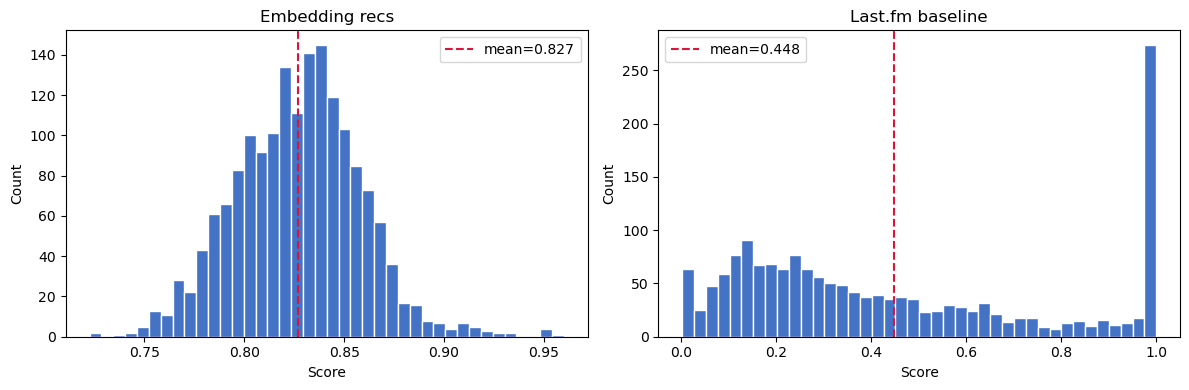

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, s, label in zip(
    axes,
    [recs_1["score"], baseline_1["score"]],
    ["Embedding recs", "Last.fm baseline"],
):
    ax.hist(s.dropna(), bins=40, color="#4472C4", edgecolor="white")
    ax.axvline(s.mean(), color="crimson", ls="--", label=f"mean={s.mean():.3f}")
    ax.set(title=label, xlabel="Score", ylabel="Count")
    ax.legend()
plt.tight_layout()
plt.show()

## Reciprocity

If A recommends B (anywhere in its top-N list), does B recommend A back? High reciprocity suggests closed neighborhoods. Total = album-to-album edges; artist = collapsed to artist-to-artist.

In [34]:
def _print_reciprocity(label, edges):
    reciprocal = sum(1 for a, b in edges if (b, a) in edges)
    rate = reciprocal / len(edges) if edges else 0
    print(f"[{label}]")
    print(f"  Edges:       {len(edges):,}")
    print(f"  Reciprocal:  {reciprocal:,}")
    print(f"  Rate:        {rate:.1%}")
    print()


def total_reciprocity(df, label):
    """If album A recommends album B, does B recommend A back?"""
    edges = set(zip(
        _norm(df["query_artist"]) + "::" + _norm(df["query_album"]),
        _norm(df["rec_artist"]) + "::" + _norm(df["rec_album"]),
    ))
    _print_reciprocity(label, edges)


def artist_reciprocity(df, label):
    """If artist A recommends artist B, does B recommend A back?"""
    edges = set(zip(_norm(df["query_artist"]), _norm(df["rec_artist"])))
    _print_reciprocity(label, edges)


print("Total reciprocity (album)")
total_reciprocity(recs_n, "embedding recs")
total_reciprocity(baseline_n, "last.fm baseline")

print("Artist reciprocity")
artist_reciprocity(recs_n, "embedding recs")
artist_reciprocity(baseline_n, "last.fm baseline")

Total reciprocity (album)
[embedding recs]
  Edges:       6,820
  Reciprocal:  98
  Rate:        1.4%

[last.fm baseline]
  Edges:       5,352
  Reciprocal:  16
  Rate:        0.3%

Artist reciprocity
[embedding recs]
  Edges:       5,937
  Reciprocal:  178
  Rate:        3.0%

[last.fm baseline]
  Edges:       4,631
  Reciprocal:  123
  Rate:        2.7%



## Novelty (self-information)

How surprising is each recommendation given the whole run? An album recommended to few queries carries more information: `-log2(share of lists containing it)`. Higher = more novel; 0 bits = recommended to every query.

In [35]:
def novelty(df, label):
    """Mean self-information of recommended albums across all lists."""
    n_lists = df.groupby(["query_artist", "query_album"], observed=True).ngroups
    key = rec_key(df)
    self_info = -np.log2(key.map(key.value_counts()) / n_lists)
    max_bits = np.log2(n_lists)
    print(f"[{label}]")
    print(f"  Lists:         {n_lists:,}")
    print(f"  Mean novelty:  {self_info.mean():.2f} bits (max {max_bits:.2f} = unique to one list)")
    print(f"  Median:        {self_info.median():.2f} bits")
    print()


novelty(recs_n, "embedding recs")
novelty(baseline_n, "last.fm baseline")

[embedding recs]
  Lists:         1,710
  Mean novelty:  9.90 bits (max 10.74 = unique to one list)
  Median:        10.74 bits

[last.fm baseline]
  Lists:         1,338
  Mean novelty:  10.16 bits (max 10.39 = unique to one list)
  Median:        10.39 bits



## Catalog coverage

What share of the review catalog (`albums.csv`) ever gets recommended? Low coverage plus high concentration means the recommender lives in a small popular neighborhood. Also reports how many rec slots go to the top 1% most-recommended albums.

In [36]:
def catalog_coverage(df, label):
    """Share of catalog albums recommended at least once + rec concentration."""
    key = rec_key(df)
    in_catalog = key.isin(catalog_reviews.index)
    recommended = set(key[in_catalog])
    counts = key.value_counts()
    top1pct = max(1, int(len(counts) * 0.01))
    top_share = counts.head(top1pct).sum() / counts.sum()
    print(f"[{label}]")
    print(f"  Rec rows in catalog:  {in_catalog.mean():.1%}")
    print(f"  Catalog coverage:     {len(recommended):,} / {len(catalog):,} albums ({len(recommended) / len(catalog):.1%})")
    print(f"  Top 1% rec albums take {top_share:.1%} of all rec slots")
    print()


catalog_coverage(recs_n, "embedding recs")
catalog_coverage(baseline_n, "last.fm baseline")

[embedding recs]
  Rec rows in catalog:  96.0%
  Catalog coverage:     4,500 / 30,516 albums (14.7%)
  Top 1% rec albums take 7.5% of all rec slots

[last.fm baseline]
  Rec rows in catalog:  32.5%
  Catalog coverage:     1,422 / 30,516 albums (4.7%)
  Top 1% rec albums take 3.3% of all rec slots



## Popularity bias

Do recommendations skew toward popular albums? Two signals:
- **review_count** (both recommenders): mean reviews of recommended in-catalog albums vs the catalog mean; ratio > 1 = popularity bias.
- **Last.fm listeners** (baseline only, from `rec_listeners` / `seed_listeners` in the batch CSV): are recommended albums more listened-to than the seeds that produced them?

In [37]:
def popularity_bias(df, label):
    """Mean review_count of recommended (in-catalog) albums vs the catalog mean."""
    rec_reviews = rec_key(df).map(catalog_reviews).dropna()
    catalog_mean = catalog_reviews.mean()
    print(f"[{label}]")
    print(f"  Matched recs:        {len(rec_reviews):,} / {len(df):,}")
    print(f"  Mean reviews (recs): {rec_reviews.mean():.2f}  |  catalog: {catalog_mean:.2f}  |  ratio: {rec_reviews.mean() / catalog_mean:.2f}x")
    print(f"  Recs with 3+ reviews: {(rec_reviews >= 3).mean():.1%}  |  catalog: {(catalog_reviews >= 3).mean():.1%}")
    print()


popularity_bias(recs_n, "embedding recs")
popularity_bias(baseline_n, "last.fm baseline")

[embedding recs]
  Matched recs:        6,564 / 6,840
  Mean reviews (recs): 1.25  |  catalog: 1.08  |  ratio: 1.15x
  Recs with 3+ reviews: 0.4%  |  catalog: 0.2%

[last.fm baseline]
  Matched recs:        1,741 / 5,352
  Mean reviews (recs): 1.28  |  catalog: 1.08  |  ratio: 1.18x
  Recs with 3+ reviews: 1.0%  |  catalog: 0.2%



In [38]:
def listener_popularity(df, label):
    """Last.fm listeners of recommended albums vs their seed albums (baseline only)."""
    sub = df.dropna(subset=["rec_listeners", "seed_listeners"])
    if sub.empty:
        print(f"[{label}]  no listener data (re-run the batch with listener collection)")
        return
    ratio = (sub["rec_listeners"] + 1) / (sub["seed_listeners"] + 1)
    print(f"[{label}]")
    print(f"  Rows with data:          {len(sub):,} / {len(df):,}")
    print(f"  Median rec listeners:    {sub['rec_listeners'].median():,.0f}")
    print(f"  Median seed listeners:   {sub['seed_listeners'].median():,.0f}")
    print(f"  Median rec/seed ratio:   {ratio.median():.2f}x")
    print(f"  Rec more popular:        {(ratio > 1).mean():.1%} of recs")
    print()


listener_popularity(baseline_n, "last.fm baseline")

[last.fm baseline]
  Rows with data:          5,346 / 5,352
  Median rec listeners:    47,433
  Median seed listeners:   33,608
  Median rec/seed ratio:   1.35x
  Rec more popular:        56.1% of recs



## Unexpectedness (vs the other recommender)

For query albums present in both systems: Jaccard overlap of the two rec lists. High overlap = the recommenders agree (mutual validation); low overlap = each contributes suggestions the other misses.

In [39]:
def rec_lists(df):
    """Map normalized query key -> set of normalized rec keys."""
    frame = pd.DataFrame({
        "query": _norm(df["query_artist"]) + "::" + _norm(df["query_album"]),
        "rec": rec_key(df),
    })
    return frame.groupby("query")["rec"].agg(set)


def unexpectedness(df_a, df_b, label_a="embedding recs", label_b="last.fm baseline"):
    lists_a, lists_b = rec_lists(df_a), rec_lists(df_b)
    shared = lists_a.index.intersection(lists_b.index)
    if shared.empty:
        print("No shared query albums between the two recommenders")
        return
    jaccard = pd.Series(
        [len(lists_a[q] & lists_b[q]) / len(lists_a[q] | lists_b[q]) for q in shared],
        index=shared,
    )
    print(f"Shared queries:     {len(shared):,}")
    print(f"Mean Jaccard:       {jaccard.mean():.1%}")
    print(f"Zero overlap:       {(jaccard == 0).mean():.1%} of queries")
    print(f"Any overlap:        {(jaccard > 0).mean():.1%} of queries")


unexpectedness(recs_n, baseline_n)

Shared queries:     1,338
Mean Jaccard:       0.6%
Zero overlap:       96.4% of queries
Any overlap:        3.6% of queries


## Serendipity-lite

Share of recs that are "relevant but not obvious": a different artist from the query *and* a below-median-popularity album (review_count within the catalog). Also reports the plain same-artist rate — the Last.fm pipeline excludes same-artist recs by design, so this mostly checks the embedding recs.

In [40]:
def serendipity_lite(df, label):
    """Different artist + below-median catalog popularity = serendipitous."""
    same_artist = _norm(df["rec_artist"]) == _norm(df["query_artist"])
    rec_reviews = rec_key(df).map(catalog_reviews)
    median_reviews = catalog_reviews.median()
    non_famous = rec_reviews <= median_reviews  # NaN (out of catalog) -> False
    serendipitous = ~same_artist & non_famous
    print(f"[{label}]")
    print(f"  Same-artist recs:   {same_artist.mean():.1%}")
    print(f"  Serendipitous:      {serendipitous.mean():.1%} (different artist, <= median popularity)")
    print(f"  (catalog median review_count: {median_reviews:.0f}; out-of-catalog recs not counted)")
    print()


serendipity_lite(recs_n, "embedding recs")
serendipity_lite(baseline_n, "last.fm baseline")

[embedding recs]
  Same-artist recs:   0.2%
  Serendipitous:      72.6% (different artist, <= median popularity)
  (catalog median review_count: 1; out-of-catalog recs not counted)

[last.fm baseline]
  Same-artist recs:   0.0%
  Serendipitous:      23.7% (different artist, <= median popularity)
  (catalog median review_count: 1; out-of-catalog recs not counted)

